In [1]:
import cv2
import numpy as np
import easyocr
import matplotlib.pyplot as plt
import os
import time

In [2]:
class TextRedactor:
    def __init__(self):
        print("Initializing Text Detector...")
        self.reader = easyocr.Reader(['en'], gpu=False, verbose=False) 

    def load_image(self, image_path):
        """Loads an image for processing."""
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image at {image_path}")
        return img

    def detect_text(self, image):
        """
        Detects text regions and formats ALL of them as polygons.
        """
        result = self.reader.detect(image)
        
        horizontal_boxes = result[0][0]
        free_form_boxes = result[1][0] 
        
        detections = []
        
        # 1. Convert Horizontal text into 4-point polygons
        if horizontal_boxes:
            for box in horizontal_boxes:
                x_min, x_max, y_min, y_max = box
                # Create the 4 corners: Top-Left, Top-Right, Bottom-Right, Bottom-Left
                pts = [
                    [int(x_min), int(y_min)],
                    [int(x_max), int(y_min)],
                    [int(x_max), int(y_max)],
                    [int(x_min), int(y_max)]
                ]
                detections.append({
                    "points": pts,
                    "conf": 1.0,
                    "text": "[.]"
                })
                
        # 2. Tilted / Rotated text (Already Polygons)
        if free_form_boxes:
            for polygon in free_form_boxes:
                pts = [[int(pt[0]), int(pt[1])] for pt in polygon]
                detections.append({
                    "points": pts,
                    "conf": 1.0,
                    "text": "[.]"
                })
                
        return detections

    def auto_redact(self, image, detections, min_conf=0.2):
        """
        Automatically applies the feathered polygon blur to all detected text.
        """
        final_img = image.copy()
        count = 0
        
        for det in detections:
            if det['conf'] >= min_conf:
                # Everything goes through the feathered polygon blur now!
                self._blur_poly(final_img, det['points'])
                count += 1
        
        print(f"Redacted {count} text regions.")
        return final_img

    def plot_preview(self, image, detections):
        """Displays the image with identified text polygons for verification."""
        display_img = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
        
        for det in detections:
            pts = np.array(det['points'], np.int32)
            pts = pts.reshape((-1, 1, 2))
            
            # Draw the polygon shape
            cv2.polylines(display_img, [pts], isClosed=True, color=(0, 255, 255), thickness=2)
            

        plt.figure(figsize=(15, 10))
        plt.imshow(display_img)
        plt.title(f"OCR Detection: {len(detections)} text blocks found")
        plt.axis('off')
        plt.show()

    def _blur_poly(self, image, polygon_points):
        
        img_h, img_w = image.shape[:2]
        np_poly = np.array(polygon_points, dtype=np.int32)

        # 1. Find boundaries of the text polygon
        min_x = np.min(np_poly[:, 0])
        max_x = np.max(np_poly[:, 0])
        min_y = np.min(np_poly[:, 1])
        max_y = np.max(np_poly[:, 1])
        
        poly_w = max_x - min_x
        poly_h = max_y - min_y

        # 2. TIGHT PADDING 
        pad_x = int(poly_w * 0.05) + 2 
        pad_y = int(poly_h * 0.05) + 2

        x1 = max(0, min_x - pad_x)
        y1 = max(0, min_y - pad_y)
        x2 = min(img_w, max_x + pad_x)
        y2 = min(img_h, max_y + pad_y)
        
        roi = image[y1:y2, x1:x2]
        if roi.size == 0: return
        roi_h, roi_w = roi.shape[:2]

        # STEP 3: FULL PIXELATION 
       
        small_w = max(2, int(roi_w * 0.05))
        small_h = max(2, int(roi_h * 0.05))
        
        # Shrink to destroy data...
        small_roi = cv2.resize(roi, (small_w, small_h), interpolation=cv2.INTER_LINEAR)
        # ...grow back using NEAREST to create giant solid blocks
        pixelated_roi = cv2.resize(small_roi, (roi_w, roi_h), interpolation=cv2.INTER_NEAREST)

        # Blur the giant blocks slightly so they aren't jagged
        bk_x, bk_y = max(15, int(roi_w * 0.2) | 1), max(15, int(roi_h * 0.2) | 1)
        blurred_roi = cv2.GaussianBlur(pixelated_roi, (bk_x, bk_y), 30)

        # --- STEP 4: FEATHERED MASKING ---
        mask = np.zeros((roi_h, roi_w), dtype=np.uint8)
        shifted_poly = np_poly - np.array([x1, y1])
        cv2.fillPoly(mask, [shifted_poly], 255)

        # Feather the mask edges 
        fk = max(11, int(min(poly_h, poly_w) * 0.3) | 1)
        mask_blurred = cv2.GaussianBlur(mask, (fk, fk), 0)

        # Alpha Blending
        mask_3d = cv2.cvtColor(mask_blurred, cv2.COLOR_GRAY2BGR)
        alpha = mask_3d.astype(float) / 255.0
        
        roi_float = roi.astype(float)
        blurred_float = blurred_roi.astype(float)
        blended = (blurred_float * alpha) + (roi_float * (1.0 - alpha))

        image[y1:y2, x1:x2] = blended.astype(np.uint8)

    def save_image(self, image, filename, folder_path="assets/savedImages"):
        """Saves the processed image."""
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        full_path = os.path.join(folder_path, filename)
        cv2.imwrite(full_path, image)
        print(f"Text-redacted image saved to: {full_path}")
        return full_path

In [3]:
t_redactor = TextRedactor()

Initializing Text Detector...


(980, 736, 3)


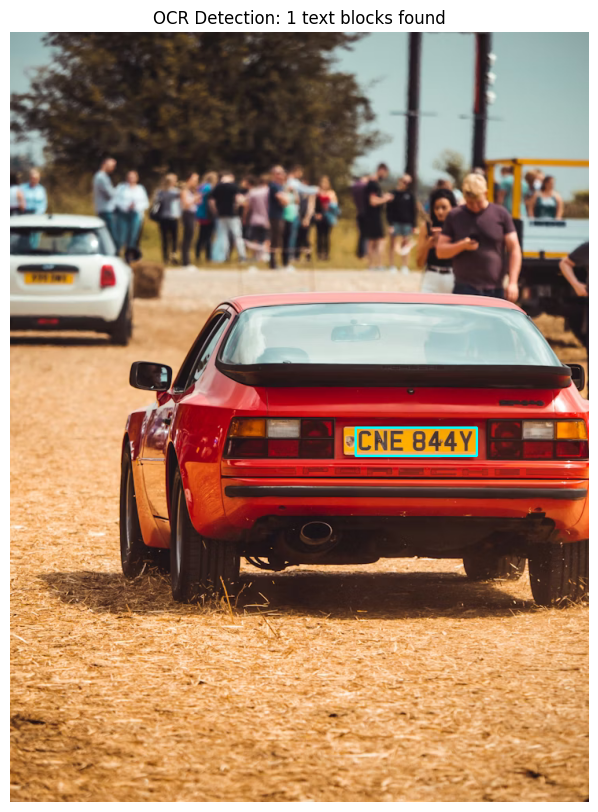

In [6]:
img = t_redactor.load_image('../assets/samples/plate.png')
print(img.shape)
detections = t_redactor.detect_text(img)
t_redactor.plot_preview(img, detections)

Redacted 1 text regions.
(980, 736, 3)


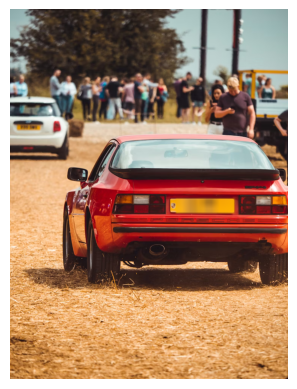

In [7]:
redacted_img = t_redactor.auto_redact(img, detections)
print(img.shape)
plt.imshow(cv2.cvtColor(redacted_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [47]:
t_redactor.save_image(redacted_img, f"text_blur{int(1e7*(time.time()-int(time.time())))}.png")

Text-redacted image saved to: assets/savedImages\text_blur5418245.png


'assets/savedImages\\text_blur5418245.png'